# NMF with TIDF and Evaluation Metrics
* TF-IDF for vectorization (downweigh overly common words)
* NMF for topic modeling
* Evaluate model quality across different k using coherence, diversity and reconstruction error <br>
--> Plot metrics
* Visualize topic space using PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.corpora import Dictionary
from sklearn.decomposition import NMF, PCA
from gensim.models import CoherenceModel
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import umap
import textwrap
from matplotlib.lines import Line2D

In [2]:
# Load preprocessed data
df = pd.read_pickle("data/preprocessed_data.pkl")
df

,id,question,link_flair_css_class,link_flair_text,clean_text,tokens
0,421zyl,How is time defined at the big bang?,physics,Physics,time define big bang,"[time, define, big, bang]"
1,4r857d,UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,ufo good scientific explanation atmospherical ...,"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,It's a commonly known fact that metals oxidize...,chem,Chemistry,commonly know fact metal oxidize possible dize...,"[commonly, know, fact, metal, oxidize, possibl..."
4,4r191k,Geoscientists: Is there any current research i...,geo,Planetary Sci.,geoscientist current research project shortfal...,"[geoscientist, current, research, project, sho..."
5,4r18ga,"Why are there so many ""accident"" babies yet so...",bio,Biology,accident baby people struggle conceive,"[accident, baby, people, struggle, conceive]"
...,...,...,...,...,...,...
612662,ry6rh0,2 doses of vaccines protect against severe ill...,med,COVID-19,dos vaccine protect severe illness infection m...,"[dos, vaccine, protect, severe, illness, infec..."
612663,ry6of6,Dentists! I've got a question for you: why do ...,med,Medicine,dentist get question dentist labeling advise c...,"[dentist, get, question, dentist, labeling, ad..."
612665,ry6nle,Why don't the oceans get saltier over time? Or...,geo,Earth Sciences,don ocean salty time,"[don, ocean, salty, time]"
612666,rwkxsm,Would tracing paper be classed as translucent ...,physics,Physics,trace paper class translucent transparent like...,"[trace, paper, class, translucent, transparent..."


## TFIDF Vectorization

In [3]:
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()

### Define Helper Functions for Evaluation Metrics & Visualization

In [4]:
# Helper functions
def get_top_words(model, feature_names, n_top=15):
    """Return top words for each topic as list of lists."""
    topics = []
    for comp in model.components_:
        top_idx = np.argsort(comp)[::-1][:n_top]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def topic_diversity(topics, topk=10):
    """Compute topic diversity: fraction of unique words among topk words."""
    top_words = [word for topic in topics for word in topic[:topk]]
    return len(set(top_words)) / len(top_words)

### NMF Loop for different values of *k*

In [5]:
# Setup
topic_nums = range(5, 101, 5)
errors, coherences, diversities = [], [], []

tokenized_docs = df['tokens'].tolist()
dictionary = Dictionary(tokenized_docs)

In [13]:
# Main loop for different values of k
for k in topic_nums:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_
    errors.append(nmf.reconstruction_err_)

    # Get top words per topic
    topics = get_top_words(nmf, feature_names, n_top=15)

    # Assign dominant topic
    df_temp = df.copy()
    df_temp['dominant_topic'] = W.argmax(axis=1)

    # Topic labels for display
    topic_labels = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
        topic_labels[topic_idx] = f"Topic {topic_idx}: {', '.join(top_words)}"

    df_temp['topic_label'] = df_temp['dominant_topic'].map(topic_labels)

    # Compute metrics
    # Topic coherence
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherences.append(coherence_model.get_coherence())
    # Topic diversity
    diversities.append(topic_diversity(topics))


Running NMF for k=5
Running NMF for k=10
Running NMF for k=15
Running NMF for k=20
Running NMF for k=25
Running NMF for k=30
Running NMF for k=35
Running NMF for k=40
Running NMF for k=45
Running NMF for k=50
Running NMF for k=55
Running NMF for k=60
Running NMF for k=65
Running NMF for k=70
Running NMF for k=75
Running NMF for k=80
Running NMF for k=85
Running NMF for k=90
Running NMF for k=95
Running NMF for k=100


### Plot Evaluation Metrics

In [16]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')
spine_color = '#cccccc'

# Build summary table
summary = pd.DataFrame({
    'k': topic_nums,
    'Coherence': coherences,
    'Diversity': diversities,
    'Reconstruction_Error': errors
})

# Normalize metrics (0–1 scale)
scaler = MinMaxScaler()
summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
    summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
)

# Calculate weighted composite score
weights = {'Coherence': 0.6, 'Diversity': 0.3, 'Reconstruction_Error': 0.1}
summary['Composite_Score'] = (
    weights['Coherence'] * summary['Coherence_norm'] +
    weights['Diversity'] * summary['Diversity_norm'] +
    weights['Reconstruction_Error'] * summary['Error_norm']
)

# Print table with scores
summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm']]

,k,Coherence,Diversity,Reconstruction_Error,Coherence_norm,Diversity_norm,Error_norm
0,5,0.560348,0.900000,703.587430,1.000000,1.000000,1.000000
1,10,0.516855,0.860000,698.282286,0.543114,0.863309,0.906506
2,15,0.512546,0.753333,693.890528,0.497849,0.498801,0.829108
3,20,0.515143,0.720000,689.857349,0.525138,0.384892,0.758031
4,25,0.484536,0.724000,686.266206,0.203618,0.398561,0.694743
5,30,0.493230,0.716667,682.890254,0.294950,0.373501,0.635247
6,35,0.497748,0.728571,679.605036,0.342402,0.414183,0.577351
7,40,0.488625,0.680000,676.650189,0.246567,0.248201,0.525277
8,45,0.496802,0.697778,673.873711,0.332469,0.308953,0.476346
9,50,0.483254,0.664000,670.922936,0.190145,0.193525,0.424344


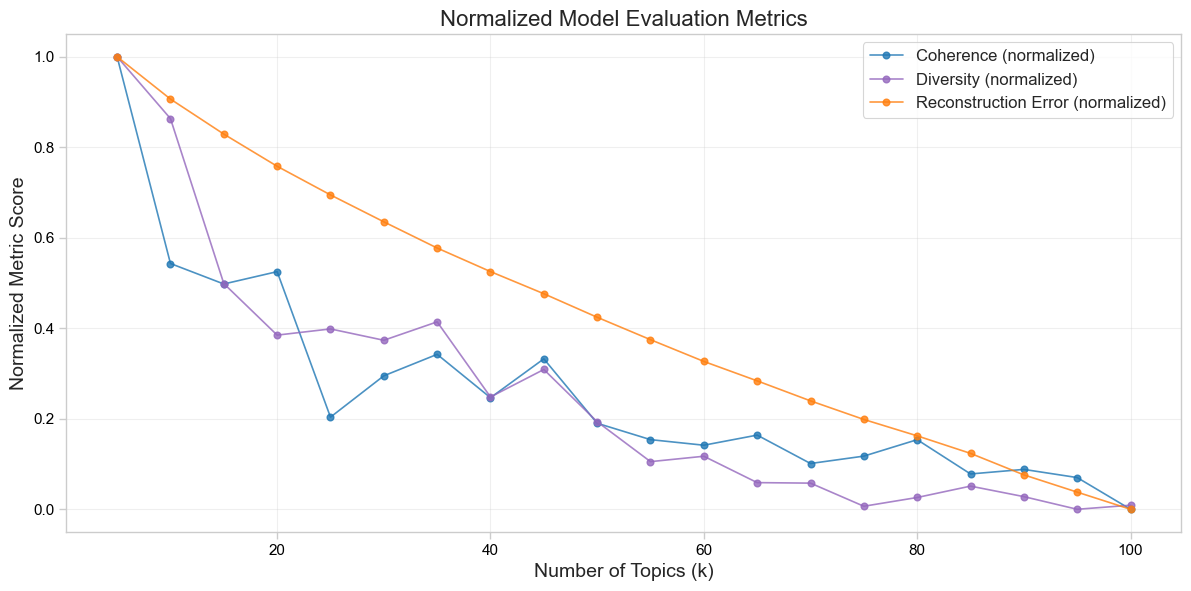

In [ ]:
# Plot model evaluation metrics
plt.figure(figsize=(10, 6))

plt.plot(summary['k'], summary['Coherence_norm'], marker='o', color='#1f77b4', label='Coherence (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Diversity_norm'], marker='o', color='#9467bd', label='Diversity (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Error_norm'], marker='o', color='#ff7f0e', label='Reconstruction Error (normalized)', alpha=0.8)

# Highlight best k
# plt.axvline(11, color='darkred', linestyle='--', label='Optimum k=11', alpha=0.8)

plt.xlabel("Number of Topics (k)", fontsize=14)
plt.ylabel("Normalized Metric Score", fontsize=14)
plt.title("Normalized Model Evaluation Metrics", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Axes & tick styling
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color(spine_color)

ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    left=True,
    color=spine_color,
    labelcolor='black',
    labelsize=11
)

plt.tight_layout()
# plt.savefig('Visualizations/nmf_all_metrics.png', dpi=300)
plt.show()

### Narrow Range for k

In [24]:
# Setup
topic_nums = range(2, 41, 1)
errors, coherences, diversities = [], [], []

tokenized_docs = df['tokens'].tolist()
dictionary = Dictionary(tokenized_docs)

In [25]:
# Main loop for different values of k
for k in topic_nums:
    print(f"Running NMF for k={k}")

    # Fit NMF model
    nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
    W = nmf.fit_transform(X)
    H = nmf.components_
    errors.append(nmf.reconstruction_err_)

    # Get top words per topic
    topics = get_top_words(nmf, feature_names, n_top=15)

    # Assign dominant topic
    df_temp = df.copy()
    df_temp['dominant_topic'] = W.argmax(axis=1)

    # Topic labels for display
    topic_labels = {}
    for topic_idx, topic in enumerate(H):
        top_words = [feature_names[i] for i in topic.argsort()[:-4:-1]]
        topic_labels[topic_idx] = f"Topic {topic_idx}: {', '.join(top_words)}"

    df_temp['topic_label'] = df_temp['dominant_topic'].map(topic_labels)

    # Compute metrics
    # Topic coherence
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherences.append(coherence_model.get_coherence())
    # Topic diversity
    diversities.append(topic_diversity(topics))


Running NMF for k=2
Running NMF for k=3
Running NMF for k=4
Running NMF for k=5
Running NMF for k=6
Running NMF for k=7
Running NMF for k=8
Running NMF for k=9
Running NMF for k=10
Running NMF for k=11
Running NMF for k=12
Running NMF for k=13
Running NMF for k=14
Running NMF for k=15
Running NMF for k=16
Running NMF for k=17
Running NMF for k=18
Running NMF for k=19
Running NMF for k=20
Running NMF for k=21
Running NMF for k=22
Running NMF for k=23
Running NMF for k=24
Running NMF for k=25
Running NMF for k=26
Running NMF for k=27
Running NMF for k=28
Running NMF for k=29
Running NMF for k=30
Running NMF for k=31
Running NMF for k=32
Running NMF for k=33
Running NMF for k=34
Running NMF for k=35
Running NMF for k=36
Running NMF for k=37
Running NMF for k=38
Running NMF for k=39
Running NMF for k=40


In [26]:
# Build summary table
summary = pd.DataFrame({
    'k': topic_nums,
    'Coherence': coherences,
    'Diversity': diversities,
    'Reconstruction_Error': errors
})

# Normalize metrics (0–1 scale)
scaler = MinMaxScaler()
summary[['Coherence_norm', 'Diversity_norm', 'Error_norm']] = scaler.fit_transform(
    summary[['Coherence', 'Diversity', 'Reconstruction_Error']]
)

# Calculate weighted composite score
weights = {'Coherence': 0.6, 'Diversity': 0.3, 'Reconstruction_Error': 0.1}
summary['Composite_Score'] = (
    weights['Coherence'] * summary['Coherence_norm'] +
    weights['Diversity'] * summary['Diversity_norm'] +
    weights['Reconstruction_Error'] * summary['Error_norm']
)

# Print table with scores
summary[['k', 'Coherence', 'Diversity', 'Reconstruction_Error', 'Coherence_norm', 'Diversity_norm', 'Error_norm']]

,k,Coherence,Diversity,Reconstruction_Error,Coherence_norm,Diversity_norm,Error_norm
0,2,0.474303,1.000000,707.440301,0.000000,1.000000,1.000000
1,3,0.508622,0.966667,706.107196,0.398844,0.895833,0.956703
2,4,0.536354,0.925000,704.830747,0.721142,0.765625,0.915247
3,5,0.560348,0.900000,703.587430,1.000000,0.687500,0.874867
4,6,0.543868,0.883333,702.422559,0.808472,0.635417,0.837034
5,7,0.540081,0.885714,701.370594,0.764458,0.642857,0.802868
6,8,0.544604,0.912500,700.307905,0.817030,0.726562,0.768354
7,9,0.524573,0.877778,699.279200,0.584230,0.618056,0.734944
8,10,0.516855,0.860000,698.282286,0.494527,0.562500,0.702566
9,11,0.513122,0.845455,697.359203,0.451151,0.517045,0.672587


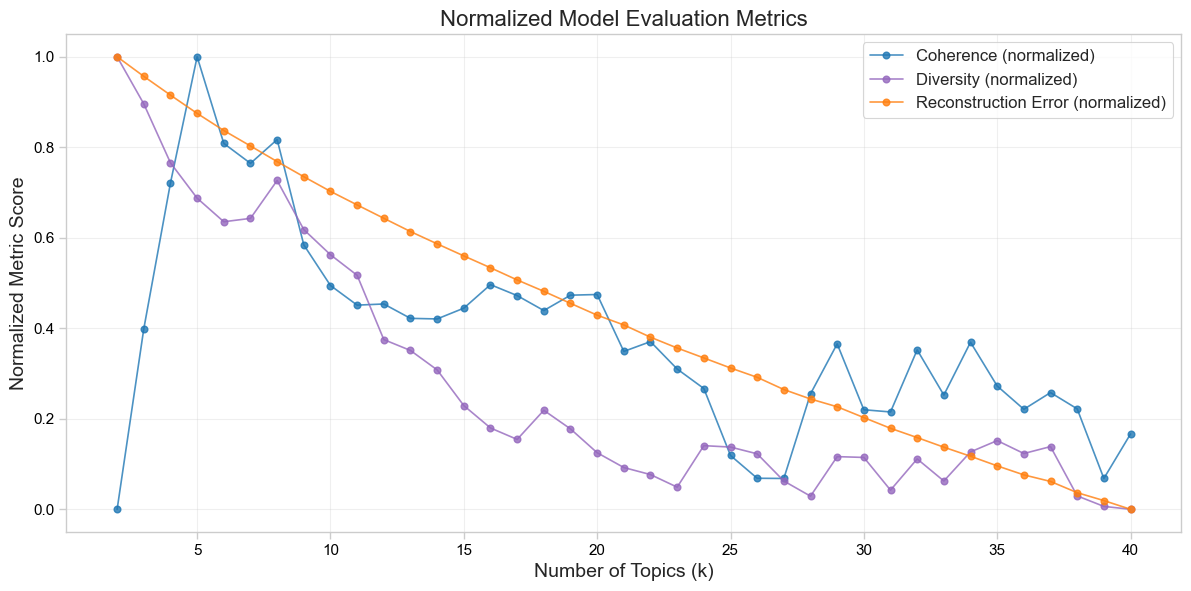

In [ ]:
# Plot model evaluation metrics
plt.figure(figsize=(10, 6))

plt.plot(summary['k'], summary['Coherence_norm'], marker='o', color='#1f77b4', label='Coherence (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Diversity_norm'], marker='o', color='#9467bd', label='Diversity (normalized)', alpha=0.8)
plt.plot(summary['k'], summary['Error_norm'], marker='o', color='#ff7f0e', label='Reconstruction Error (normalized)', alpha=0.8)

# Highlight best k
# plt.axvline(11, color='darkred', linestyle='--', label='Optimum k=11', alpha=0.8)

plt.xlabel("Number of Topics (k)", fontsize=14)
plt.ylabel("Normalized Metric Score", fontsize=14)
plt.title("Normalized Model Evaluation Metrics", fontsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Axes & tick styling
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color(spine_color)

ax.tick_params(
    axis='both',
    which='both',
    bottom=True,
    left=True,
    color=spine_color,
    labelcolor='black',
    labelsize=11
)

plt.tight_layout()
plt.savefig('viz/NMF_evaluation_metrics.png', dpi=300)
plt.show()

## NMF with Best Values for *k*

In [21]:
# k = 5
# k = 8
k = 16

nmf = NMF(n_components=k, random_state=42, init='nndsvda', max_iter=1000)
W = nmf.fit_transform(X)
H = nmf.components_

# Print top words per topic
num_top_words = 10
for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-num_top_words - 1:-1]
    top_words = [feature_names[i] for i in top_indices]

# Get top words per topic
topics = get_top_words(nmf, feature_names, n_top=15)
pd.DataFrame(topics).to_csv(f"topics/topic_words_k{k}.csv", index_label="Topic")

for topic in topics:
    print(topic)

['human', 'animal', 'specie', 'evolve', 'brain', 'evolution', 'long', 'live', 'dog', 'survive', 'eye', 'able', 'way', 'evolutionary', 'life']
['light', 'speed', 'travel', 'fast', 'object', 'move', 'sound', 'year', 'slow', 'away', 'wave', 'photon', 'reach', 'visible', 'eye']
['earth', 'moon', 'sun', 'orbit', 'gravity', 'atmosphere', 'life', 'rotation', 'year', 'surface', 'long', 'mar', 'affect', 'away', 'asteroid']
['black', 'hole', 'mass', 'horizon', 'event', 'matter', 'star', 'white', 'escape', 'singularity', 'inside', 'gravity', 'fall', 'radiation', 'hawk']
['water', 'drink', 'cold', 'hot', 'temperature', 'ice', 'air', 'ocean', 'boil', 'salt', 'freeze', 'liquid', 'bottle', 'heat', 'pressure']
['covid', 'vaccine', 'long', 'virus', 'effect', 'get', 'test', 'term', 'mrna', 'work', 'immunity', 'flu', 'infection', 'disease', 'new']
['happen', 'brain', 'actually', 'suddenly', 'person', 'stop', 'get', 'exactly', 'die', 'disappear', 'hit', 'inside', 'world', 'collide', 'turn']
['time', 'trav

In [22]:
# Assign dominant topic
df_temp = df.copy()
df_temp['dominant_topic'] = W.argmax(axis=1)

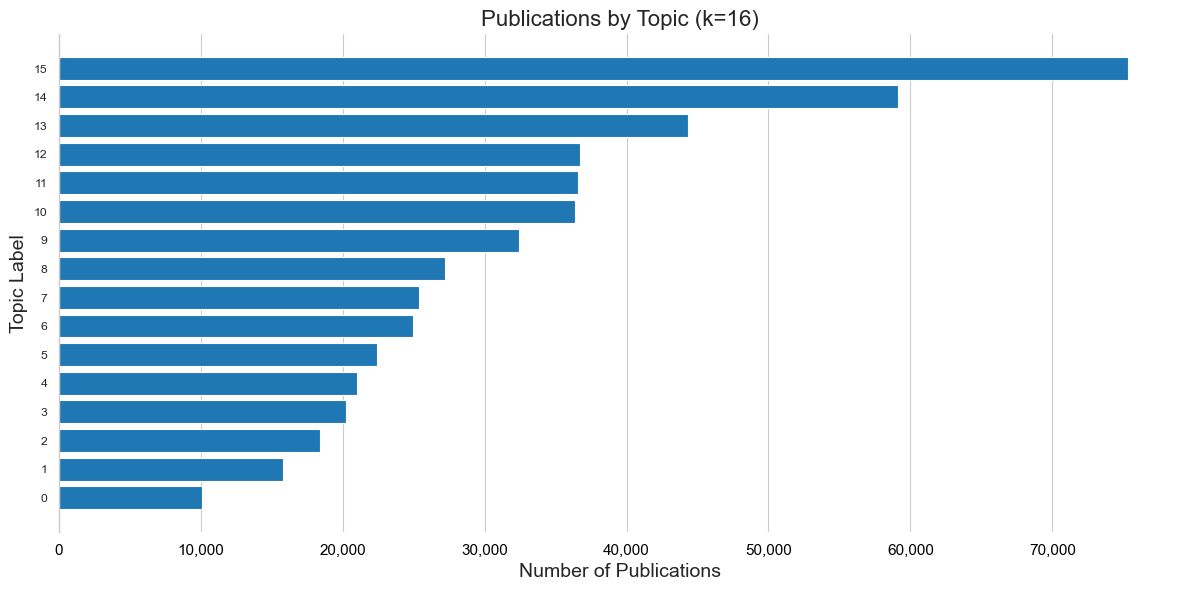

In [23]:
# Visualize distribution of posts across topics
fig, ax = plt.subplots(figsize=(12, 6))

# Count documents per topic and sort ascending for horizontal bar
topic_counts = df_temp['dominant_topic'].value_counts().sort_values(ascending=True)
topics_sorted = topic_counts.index

# Wrap labels and append topic number
#wrapped_labels = [
#"\n".join(textwrap.wrap(f"{topic_labels[t]}", width=25))
#for t in topics_sorted
#]

# Horizontal bar plot
ax.barh(
    y=range(len(topics_sorted)),
    width=topic_counts.values,
    color="#1f77b4"
)

# y-Axis labels
ax.set_yticks(range(len(topics_sorted)))
# ax.set_yticklabels(wrapped_labels, fontsize=11)

# Labels and title
ax.set_xlabel("Number of Publications", fontsize=14)
ax.set_ylabel("Topic Label", fontsize=14)
ax.set_title(f"Publications by Topic (k={k})", fontsize=16)

# Tick labels
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='x', colors='black', labelsize=11)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(f'viz/NMF_posts_per_topic_k{k}.png', dpi=300)
plt.show()

### Projection into 2-D Space

In [24]:
# Create color map for topics
topic_ids = sorted(df_temp['dominant_topic'].unique())
cmap = plt.colormaps.get_cmap('tab20')
colors = [cmap(i) for i in range(len(topic_ids))]
color_map = {t: colors[i % len(colors)] for i, t in enumerate(topic_ids)}
topic_colors = df_temp['dominant_topic'].map(color_map)

# PCA projection
pca = PCA(n_components=2, random_state=42)
W_pca = pca.fit_transform(W)

# UMAP projection
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, n_jobs=-1)
W_umap = reducer.fit_transform(W)

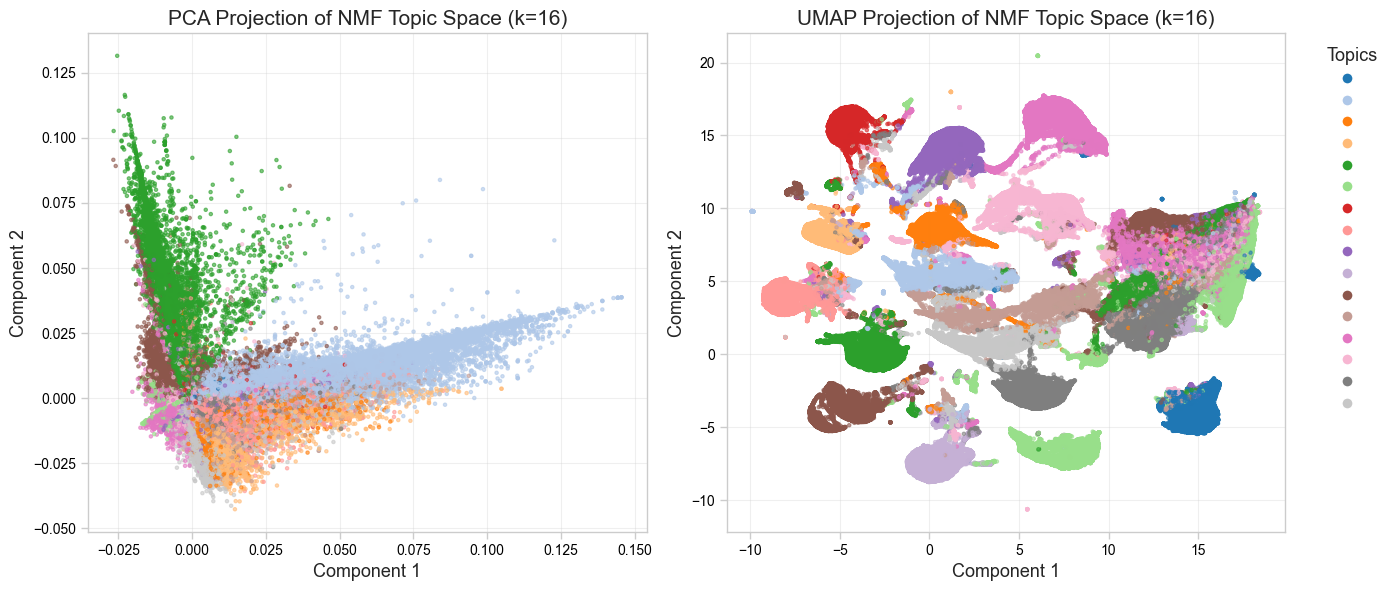

In [25]:
# Plot style
sns.set_theme(style='whitegrid', context='paper')
spine_color = '#cccccc'

# Plot Projections
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
titles = ["PCA Projection", "UMAP Projection"]

for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
    ax.scatter(
        emb[:, 0], emb[:, 1],
        c=topic_colors,
        s=6,
        alpha=0.6
    )
    ax.set_title(f"{title} of NMF Topic Space (k={k})", fontsize=15)
    ax.set_xlabel("Component 1", fontsize=13)
    ax.set_ylabel("Component 2", fontsize=13)
    ax.grid(alpha=0.3)
    for spine in ax.spines.values():
        spine.set_color("#cccccc")
    ax.tick_params(axis='both', which='both', labelsize=10)

# Shared Legend
legend_elements = [
    Line2D(
        [0], [0],
        marker='o', color='w',
        markerfacecolor=color_map[t],
        markersize=8
        # label="\n".join(textwrap.wrap(topic_labels.get(t, f"Topic {t}"), width=18))
    )
    for t in topic_ids
    ]
axes[1].legend(
    handles=legend_elements,
    title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=11,
    title_fontsize=13,
    ncol=1,
    frameon=False
)

# Axis ticks
for ax in axes:
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        left=True,
        color=spine_color,
        labelcolor='black'
    )

plt.tight_layout()
plt.savefig(f'viz/nmf_pca_vs_umap_k{k}.png', dpi=300, bbox_inches='tight')
plt.show()